#  Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

print("All libraries imported successfully")

All libraries imported successfully


# Load the Dataset

In [5]:
df = pd.read_csv('../data/forest_cover.csv')

print(f"Dataset Loaded! Shape: {df.shape}")
df.head()

Dataset Loaded! Shape: (145890, 13)


,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,Cover_Type,Wilderness_Area,Soil_Type
0,2596,51,3,258,0,510,221,232,148,6279,Aspen,1,29
1,2590,56,2,212,-6,390,220,235,151,6225,Aspen,1,29
2,2804,139,9,268,65,3180,234,238,135,6121,Lodgepole Pine,1,12
3,2785,155,18,242,118,3090,238,238,122,6211,Lodgepole Pine,1,30
4,2595,45,2,153,-1,391,220,234,150,6172,Aspen,1,29


# Separate Columns by Type

In [8]:
# Let's separate columns into 3 groups:
# 1. Numerical columns  
# 2. Categorical columns
# 3. Target column

target_col = 'Cover_Type'

categorical_cols = ['Wilderness_Area', 'Soil_Type']

numerical_cols = [col for col in df.columns 
                  if col not in categorical_cols + [target_col]]

print("Numerical columns:", numerical_cols)
print("\n Categorical columns:", categorical_cols)
print("\n Target column:", target_col)

Numerical columns: ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']

 Categorical columns: ['Wilderness_Area', 'Soil_Type']

 Target column: Cover_Type


# Check Missing Values Again

In [13]:
# Double check missing values

print("=== MISSING VALUES PER COLUMN ===")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

=== MISSING VALUES PER COLUMN ===
Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Cover_Type                            0
Wilderness_Area                       0
Soil_Type                             0
dtype: int64

Total missing values: 0


# Check Outliers Using IQR Method

In [20]:
# IQR Method to detect outliers in numerical columns
# IQR = Inter Quartile Range = Q3 - Q1
# Anything below Q1-1.5*IQR or above Q3+1.5*IQR is an outlier

print("=== OUTLIER DETECTION USING IQR ===\n")

outlier_summary = {}

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound)  | (df[col] > upper_bound)]
    outlier_count = len(outliers)
    outlier_summary[col] = outlier_count

    print(f"{col}:")
    print(f" Lower Bound: {lower_bound: .2f} | Upper Bound: {upper_bound:.2f}")
    print(f" Outliers found: {outlier_count}\n")
    

=== OUTLIER DETECTION USING IQR ===

Elevation:
 Lower Bound:  2361.50 | Upper Bound: 3389.50
 Outliers found: 4448

Aspect:
 Lower Bound: -190.50 | Upper Bound: 461.50
 Outliers found: 0

Slope:
 Lower Bound: -5.00 | Upper Bound: 27.00
 Outliers found: 3385

Horizontal_Distance_To_Hydrology:
 Lower Bound: -305.50 | Upper Bound: 762.50
 Outliers found: 2473

Vertical_Distance_To_Hydrology:
 Lower Bound: -59.00 | Upper Bound: 117.00
 Outliers found: 7123

Horizontal_Distance_To_Roadways:
 Lower Bound: -2389.50 | Upper Bound: 8910.50
 Outliers found: 0

Hillshade_9am:
 Lower Bound:  169.50 | Upper Bound: 269.50
 Outliers found: 5242

Hillshade_Noon:
 Lower Bound:  186.00 | Upper Bound: 266.00
 Outliers found: 3211

Hillshade_3pm:
 Lower Bound:  64.00 | Upper Bound: 216.00
 Outliers found: 3087

Horizontal_Distance_To_Fire_Points:
 Lower Bound: -2697.00 | Upper Bound: 8783.00
 Outliers found: 0



# Visualize Outliers Using Boxplots

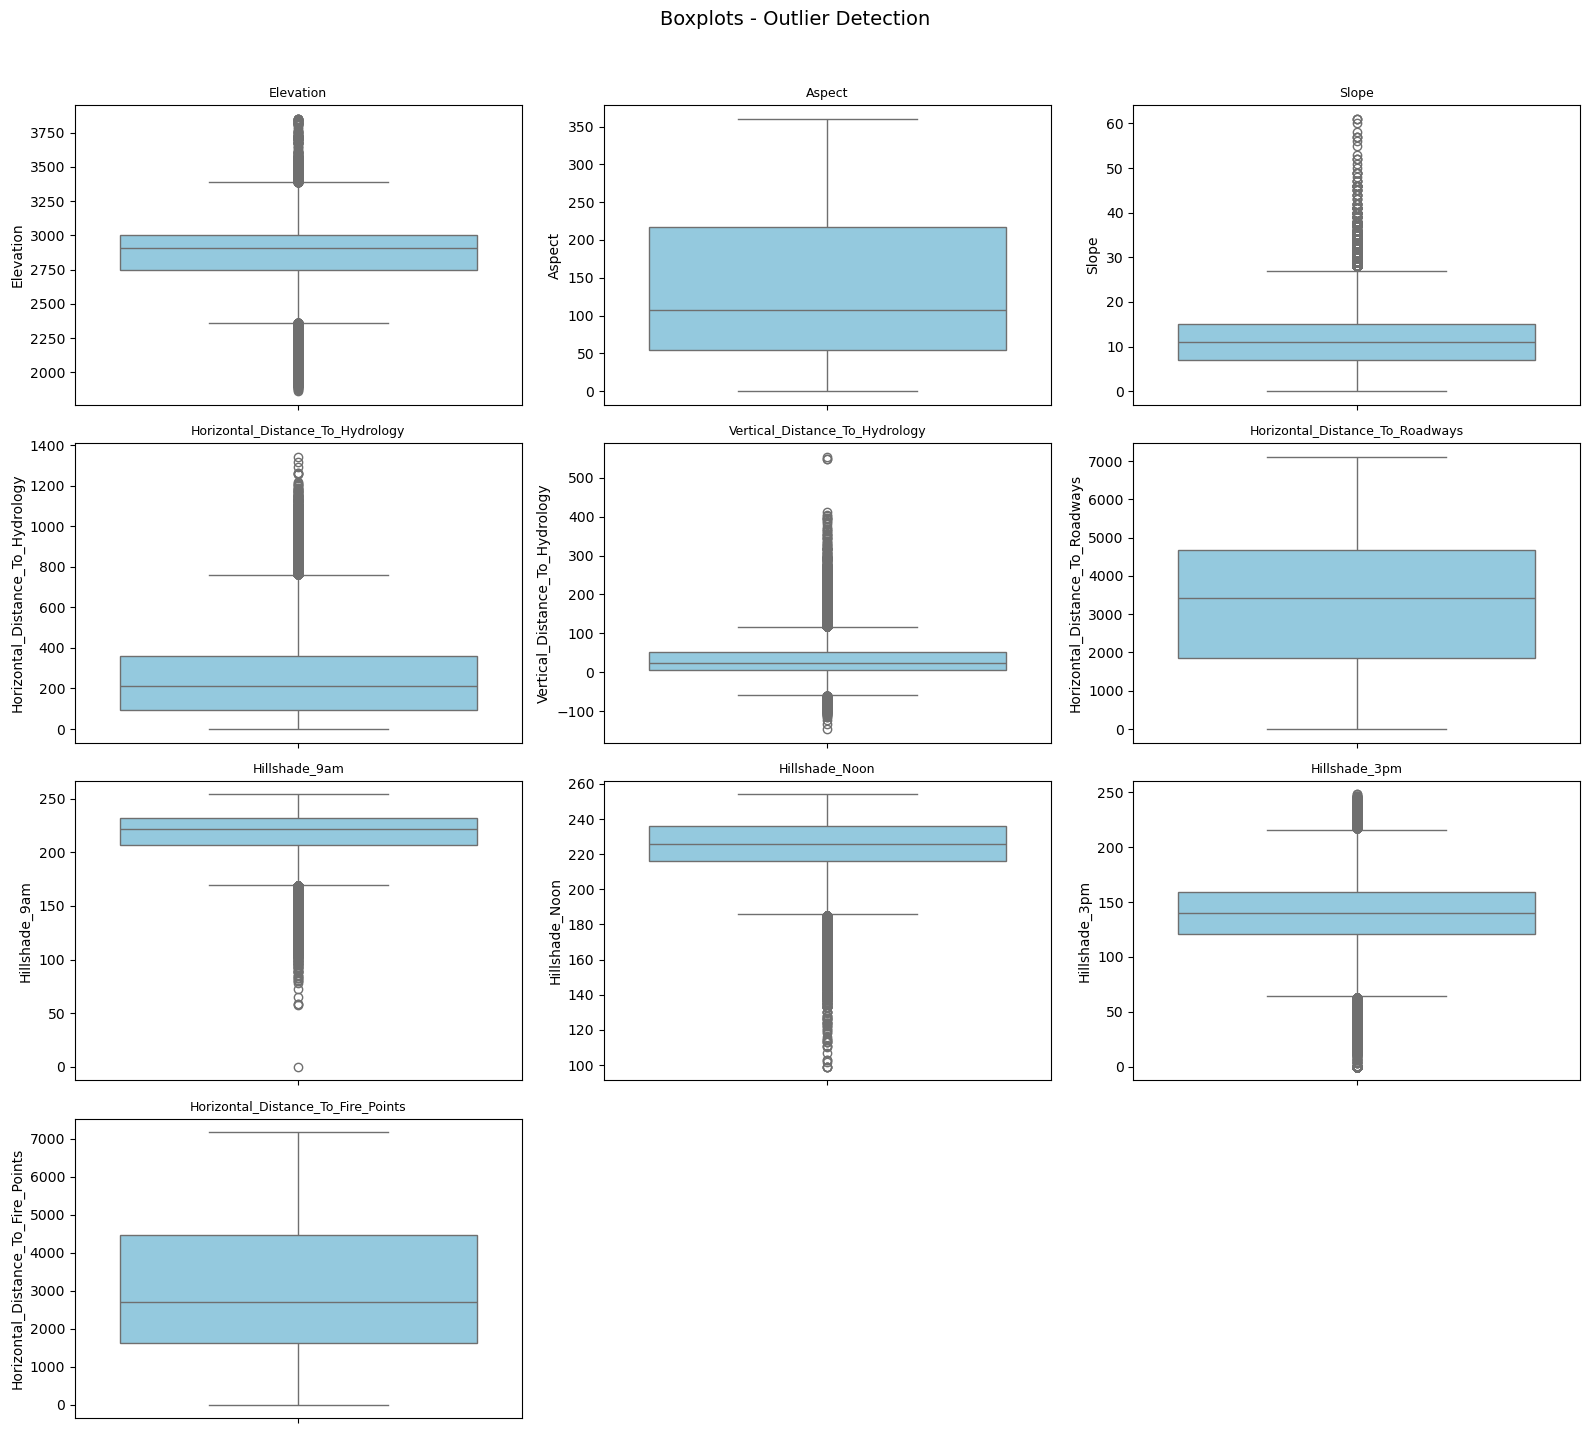

In [25]:
# Boxplot shows outliers visually as dots outside the whiskers

plt.figure(figsize=(16, 14))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(y=df[col], color='skyblue')
    plt.title(f'{col}', fontsize=9)
    plt.tight_layout()

plt.suptitle('Boxplots - Outlier Detection',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Cap Outliers Using IQR (Capping Method)

In [28]:
# Instead of REMOVING outlier rows (we'd lose too much data),
# we CAP them — push them to the boundary value
# This is called Winsorization

df_cleaned = df.copy()

print("=== CAPPING OUTLIERS ===\n")

for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR 

    # Cap values below lower bound to lower bound
    # Cap values above upper bound to upper bound
    df_cleaned[col] = df_cleaned[col].clip(lower=lower_bound, 
                                            upper=upper_bound)

print("Outliers capped successfully for all numerical columns!")
print(f"Shape after capping: {df_cleaned.shape}")
    

=== CAPPING OUTLIERS ===

Outliers capped successfully for all numerical columns!
Shape after capping: (145890, 13)


#  Check Skewness in Numerical Columns

In [31]:
# Skewness measures how lopsided a distribution is
# Skewness > 1 or < -1 means the column is heavily skewed
# We need to fix skewness before training ML models

print("=== SKEWNESS CHECK ===\n")

skewness = df_cleaned[numerical_cols].skew().sort_values(ascending=False)

for col, skew_val in skewness.items():
    status = ""
    if abs(skew_val) > 1:
        status = "HIGH SKEW — needs fixing"
    elif abs(skew_val) > 0.5:
        status = "MODERATE SKEW"
    else:
        status = "Normal"
    print(f"{col}: {skew_val:.4f}  {status}")

=== SKEWNESS CHECK ===

Vertical_Distance_To_Hydrology: 0.8613  MODERATE SKEW
Horizontal_Distance_To_Hydrology: 0.7923  MODERATE SKEW
Aspect: 0.6894  MODERATE SKEW
Slope: 0.6214  MODERATE SKEW
Horizontal_Distance_To_Fire_Points: 0.3652  Normal
Hillshade_3pm: -0.0012  Normal
Horizontal_Distance_To_Roadways: -0.0582  Normal
Elevation: -0.3404  Normal
Hillshade_Noon: -0.5054  MODERATE SKEW
Hillshade_9am: -0.7404  MODERATE SKEW


# Fix Skewness Using log1p Transformation

In [34]:
# log1p means log(1 + value)
# We use log1p instead of log because log(0) is undefined
# log1p works even when value = 0

# Only fix columns with high skewness (abs > 1)
high_skew_cols = skewness[abs(skewness) > 1].index.tolist()

print(f"Columns needing skewness fix: {high_skew_cols}\n")

for col in high_skew_cols:
    # Check if all values are non-negative before applying log1p
    if df_cleaned[col].min() >= 0:
        df_cleaned[col] = np.log1p(df_cleaned[col])
        print(f"Applied log1p to: {col}")
    else:
        print(f"Skipped {col} — has negative values")

print("\n Skewness treatment done!")

Columns needing skewness fix: []


 Skewness treatment done!


# Verify Skewness After Fixing

In [37]:
# Check skewness again after transformation
print("=== SKEWNESS AFTER FIXING ===\n")

skewness_after = df_cleaned[numerical_cols].skew().sort_values(ascending=False)

for col, skew_val in skewness_after.items():
    status = ""
    if abs(skew_val) > 1:
        status = "⚠STILL HIGH"
    elif abs(skew_val) > 0.5:
        status = "MODERATE"
    else:
        status = "Good"
    print(f"{col}: {skew_val:.4f}  {status}")

=== SKEWNESS AFTER FIXING ===

Vertical_Distance_To_Hydrology: 0.8613  MODERATE
Horizontal_Distance_To_Hydrology: 0.7923  MODERATE
Aspect: 0.6894  MODERATE
Slope: 0.6214  MODERATE
Horizontal_Distance_To_Fire_Points: 0.3652  Good
Hillshade_3pm: -0.0012  Good
Horizontal_Distance_To_Roadways: -0.0582  Good
Elevation: -0.3404  Good
Hillshade_Noon: -0.5054  MODERATE
Hillshade_9am: -0.7404  MODERATE


# Save the Cleaned Data

In [40]:
# Save the cleaned dataframe so Notebook 3 can use it
# We save it as a new file — original stays untouched

df_cleaned.to_csv('../data/forest_cover_cleaned.csv', index=False)

print("Cleaned data saved as 'forest_cover_cleaned.csv'")
print(f"Final shape: {df_cleaned.shape}")

Cleaned data saved as 'forest_cover_cleaned.csv'
Final shape: (145890, 13)


## 📝 Summary from Notebook 2

- Reloaded original dataset: 145,891 rows × 13 columns
- Missing values: 0 — nothing to impute
- Outliers: Detected using IQR method in all 10 numerical columns
- Outlier treatment: Capped using clip() — no rows deleted
- Skewness check: No HIGH skewness found (all columns below 1.0)
- Moderate skewness found in: Vertical_Distance_To_Hydrology,
  Horizontal_Distance_To_Hydrology, Aspect, Slope, 
  Hillshade_Noon, Hillshade_9am
- log1p transformation: Not needed — skewness within acceptable range
- Saved cleaned file: forest_cover_cleaned.csv
- Next step: Notebook 3 - EDA & Visualization